# House Price Prediction using Linear Regression

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv("../data/AmesHousing.csv")

In [4]:
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.shape

(2930, 82)

In [6]:
df.columns

Index(['Order', 'PID', 'MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area',
       'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual',
       'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style',
       'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type',
       'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual',
       'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1',
       'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF',
       'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF',
       '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath',
       'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr',
       'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional',
       'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt',
      

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

In [8]:
df.describe()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.00000,2.930000e+03,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,1465.50000,7.144645e+08,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,845.96247,1.887308e+08,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,1.00000,5.263011e+08,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,733.25000,5.284770e+08,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,1465.50000,5.354536e+08,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,2197.75000,9.071811e+08,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,2930.00000,1.007100e+09,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [9]:
df.describe(include="object")

,MS Zoning,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Pool QC,Fence,Misc Feature,Sale Type,Sale Condition
count,2930,2930,198,2930,2930,2930,2930,2930,2930,2930,...,2773,2771,2771,2771,2930,13,572,106,2930,2930
unique,7,2,2,4,4,3,5,3,28,9,...,6,3,5,5,3,4,4,5,10,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,2273,2918,120,1859,2633,2927,2140,2789,443,2522,...,1731,1231,2615,2665,2652,4,330,95,2536,2413


In [10]:
df.isnull().sum()

Order               0
PID                 0
MS SubClass         0
MS Zoning           0
Lot Frontage      490
                 ... 
Mo Sold             0
Yr Sold             0
Sale Type           0
Sale Condition      0
SalePrice           0
Length: 82, dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum() / len(df)) * 100
})

missing = missing[missing["Missing Values"] > 0]
missing.sort_values(by="Percentage", ascending=False)

,Missing Values,Percentage
Pool QC,2917,99.556314
Misc Feature,2824,96.382253
Alley,2732,93.242321
Fence,2358,80.477816
Mas Vnr Type,1775,60.580205
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Cond,159,5.426621
Garage Qual,159,5.426621
Garage Finish,159,5.426621


### Dropping Columns with High Missing Values

Some features contain more than 60–99% missing values. Since most observations lack these values, these columns provide limited information for model training. Therefore, they are removed from the dataset.

In [13]:
columns_to_drop = [
    'Pool QC',
    'Misc Feature',
    'Alley',
    'Fence',
    'Mas Vnr Type'
]

df.drop(columns=columns_to_drop, inplace=True)

print("Remaining columns:", df.shape[1])

Remaining columns: 77


In [14]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing = missing[missing["Missing Values"] > 0]
missing.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Fireplace Qu,1422,48.532423
Lot Frontage,490,16.723549
Garage Qual,159,5.426621
Garage Finish,159,5.426621
Garage Yr Blt,159,5.426621
Garage Cond,159,5.426621
Garage Type,157,5.358362
Bsmt Exposure,83,2.832765
BsmtFin Type 2,81,2.764505
BsmtFin Type 1,80,2.730375


In [15]:
bsmt_cat = [
    'Bsmt Qual',
    'Bsmt Cond',
    'Bsmt Exposure',
    'BsmtFin Type 1',
    'BsmtFin Type 2'
]

for col in bsmt_cat:
    df[col] = df[col].fillna('None')

In [16]:
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

In [17]:
df[[
    'Garage Yr Blt',
    'Garage Type',
    'Garage Qual',
    'Bsmt Qual'
]].isnull().sum()

Garage Yr Blt      0
Garage Type      157
Garage Qual      159
Bsmt Qual          0
dtype: int64

In [18]:
df.isnull().sum().sort_values(ascending=False).head(10)

Fireplace Qu      1422
Lot Frontage       490
Garage Cond        159
Garage Finish      159
Garage Qual        159
Garage Type        157
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
Total Bsmt SF        1
dtype: int64

In [19]:
df['Fireplace Qu'] = df['Fireplace Qu'].fillna('None')

In [20]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

In [21]:
garage_num = [
    'Garage Yr Blt',
    'Garage Cars',
    'Garage Area'
]

for col in garage_num:
    df[col] = df[col].fillna(0)

In [22]:
bsmt_num = [
    'BsmtFin SF 1',
    'BsmtFin SF 2',
    'Bsmt Unf SF',
    'Total Bsmt SF',
    'Bsmt Full Bath',
    'Bsmt Half Bath'
]

for col in bsmt_num:
    df[col] = df[col].fillna(0)

In [23]:
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)

In [24]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [25]:
df.isnull().sum().sum()

np.int64(634)

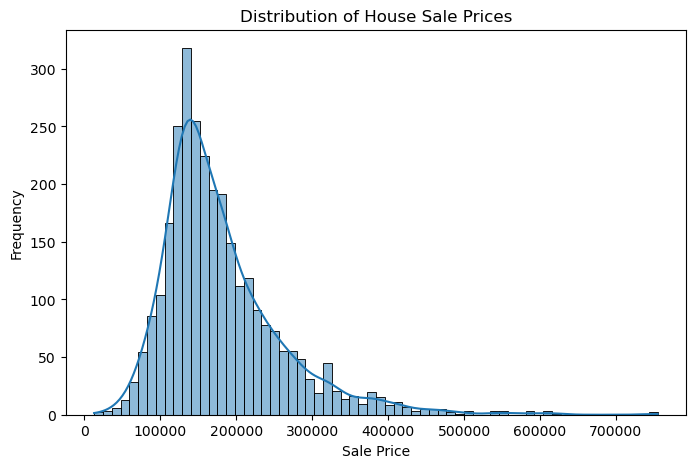

In [26]:
plt.figure(figsize=(8,5))
sns.histplot(df['SalePrice'], kde=True)

plt.title('Distribution of House Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

plt.savefig("../images/histogram_saleprice.png", dpi=300, bbox_inches='tight')

plt.show()

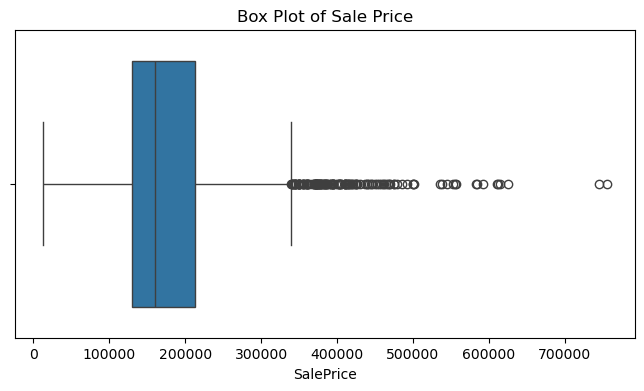

In [27]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['SalePrice'])

plt.title('Box Plot of Sale Price')

plt.savefig("../images/boxplot_saleprice.png", dpi=300, bbox_inches='tight')

plt.show()

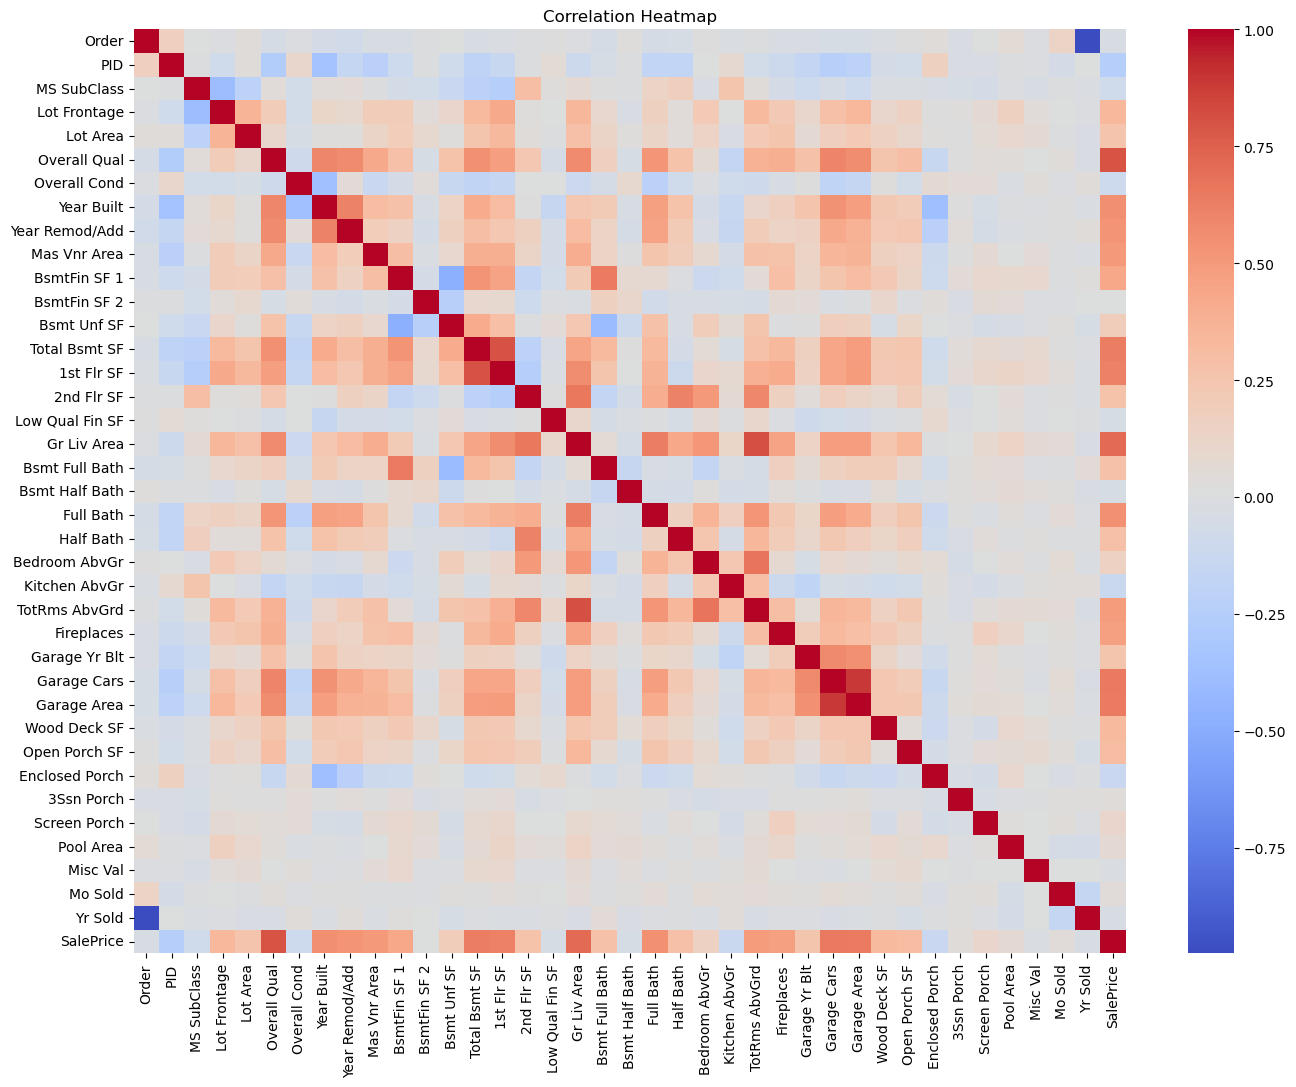

In [54]:
plt.figure(figsize=(16,12))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.savefig("../images/correlation_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

In [29]:
saleprice_corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)

saleprice_corr

SalePrice          1.000000
Overall Qual       0.799262
Gr Liv Area        0.706780
Garage Cars        0.647562
Garage Area        0.640138
Total Bsmt SF      0.632529
1st Flr SF         0.621676
Year Built         0.558426
Full Bath          0.545604
Year Remod/Add     0.532974
Mas Vnr Area       0.502196
TotRms AbvGrd      0.495474
Fireplaces         0.474558
BsmtFin SF 1       0.433147
Lot Frontage       0.340256
Wood Deck SF       0.327143
Open Porch SF      0.312951
Half Bath          0.285056
Bsmt Full Bath     0.275823
2nd Flr SF         0.269373
Lot Area           0.266549
Garage Yr Blt      0.253459
Bsmt Unf SF        0.183308
Bedroom AbvGr      0.143913
Screen Porch       0.112151
Pool Area          0.068403
Mo Sold            0.035259
3Ssn Porch         0.032225
BsmtFin SF 2       0.006018
Misc Val          -0.015691
Yr Sold           -0.030569
Order             -0.031408
Bsmt Half Bath    -0.035817
Low Qual Fin SF   -0.037660
MS SubClass       -0.085092
Overall Cond      -0

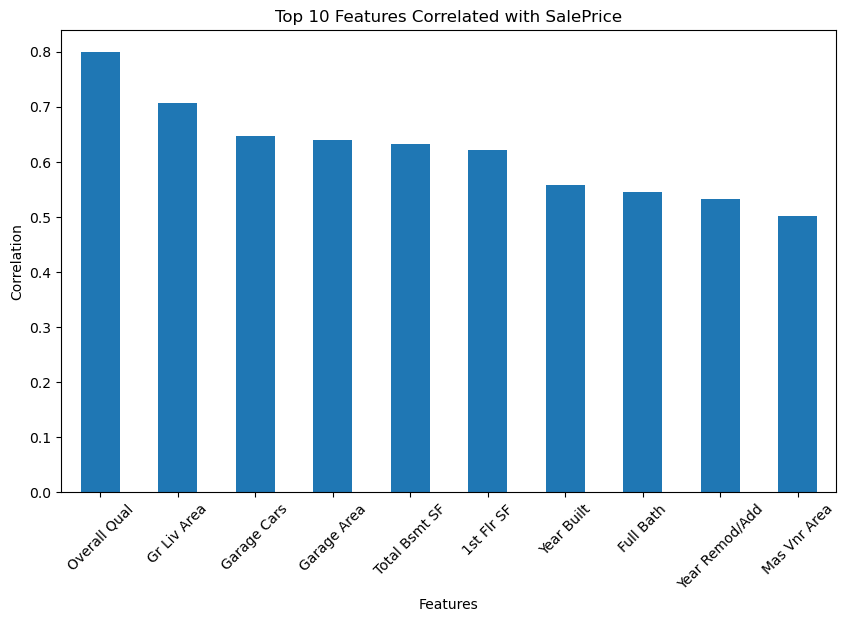

In [55]:
plt.figure(figsize=(10,6))

saleprice_corr[1:11].plot(kind='bar')

plt.title('Top 10 Features Correlated with SalePrice')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=45)

plt.savefig("../images/top10_correlation.png", dpi=300, bbox_inches='tight')

plt.show()

In [31]:
df.dtypes

Order               int64
PID                 int64
MS SubClass         int64
MS Zoning          object
Lot Frontage      float64
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type          object
Sale Condition     object
SalePrice           int64
Length: 77, dtype: object

In [32]:
cat_cols = df.select_dtypes(include='object').columns

print("Number of categorical columns:", len(cat_cols))
cat_cols

Number of categorical columns: 38


Index(['MS Zoning', 'Street', 'Lot Shape', 'Land Contour', 'Utilities',
       'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Exter Qual', 'Exter Cond',
       'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Sale Type', 'Sale Condition'],
      dtype='object')

In [33]:
df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True,
    dtype=int
)

In [34]:
df_encoded.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,1,526301100,20,141.0,31770,6,5,1960,1960,112.0,...,0,0,0,0,1,0,0,0,1,0
1,2,526350040,20,80.0,11622,5,6,1961,1961,0.0,...,0,0,0,0,1,0,0,0,1,0
2,3,526351010,20,81.0,14267,6,6,1958,1958,108.0,...,0,0,0,0,1,0,0,0,1,0
3,4,526353030,20,93.0,11160,7,5,1968,1968,0.0,...,0,0,0,0,1,0,0,0,1,0
4,5,527105010,60,74.0,13830,5,5,1997,1998,0.0,...,0,0,0,0,1,0,0,0,1,0


In [35]:
df_encoded.shape

(2930, 255)

In [36]:
df_encoded.dtypes.unique()

array([dtype('int64'), dtype('float64')], dtype=object)

## Feature Selection

Before training the model, the dataset is divided into:

- **Features (X):** All independent variables used to predict house prices.
- **Target (y):** The dependent variable (`SalePrice`), which the model will learn to predict.

In [37]:
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']

In [38]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (2930, 254)
Target Shape: (2930,)


In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [40]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2344, 254)
X_test : (586, 254)
y_train: (2344,)
y_test : (586,)


## Linear Regression Model

A Linear Regression model is trained using the training dataset to learn the relationship between the house features and the target variable (`SalePrice`).

In [41]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred = model.predict(X_test)

In [43]:
prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

prediction_df.head(10)

,Actual Price,Predicted Price
0,161000,159127.375653
1,116000,110118.621478
2,196500,193911.471409
3,123600,135187.954316
4,126000,131991.046049
5,174190,190824.464109
6,200000,162638.295518
7,148500,144078.339250
8,88750,104478.749597
9,409900,368773.776555


## Model Evaluation

After training the Linear Regression model, its performance is evaluated using standard regression metrics.

The following evaluation metrics are used:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

In [44]:
mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 844643036.2409256
Root Mean Squared Error (RMSE): 29062.743095601378
R² Score: 0.8946507032424695


In [45]:
prediction_df = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

prediction_df.head(10)

,Actual Price,Predicted Price
0,161000,159127.375653
1,116000,110118.621478
2,196500,193911.471409
3,123600,135187.954316
4,126000,131991.046049
5,174190,190824.464109
6,200000,162638.295518
7,148500,144078.339250
8,88750,104478.749597
9,409900,368773.776555


## Actual vs Predicted Prices

A scatter plot is used to compare the actual house prices with the predicted house prices. Points closer to the diagonal line indicate better model performance.

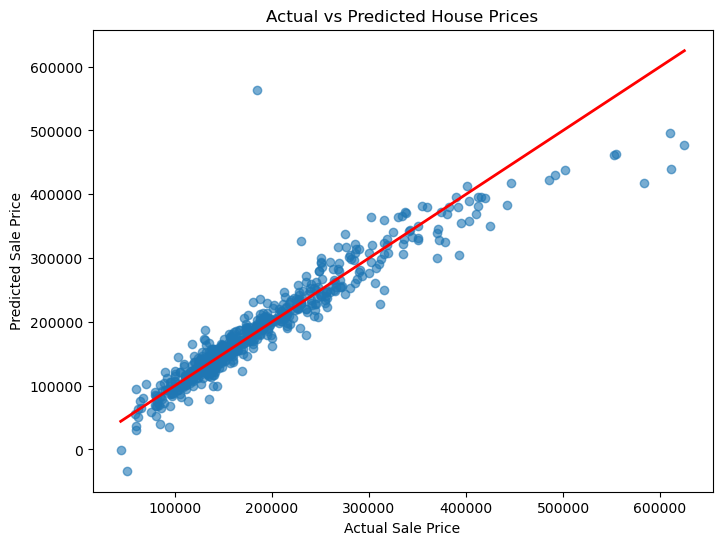

In [56]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.title("Actual vs Predicted House Prices")

plt.savefig("../images/actual_vs_predicted.png", dpi=300, bbox_inches='tight')

plt.show()

## Residual Analysis

In [47]:
residuals = y_test - y_pred

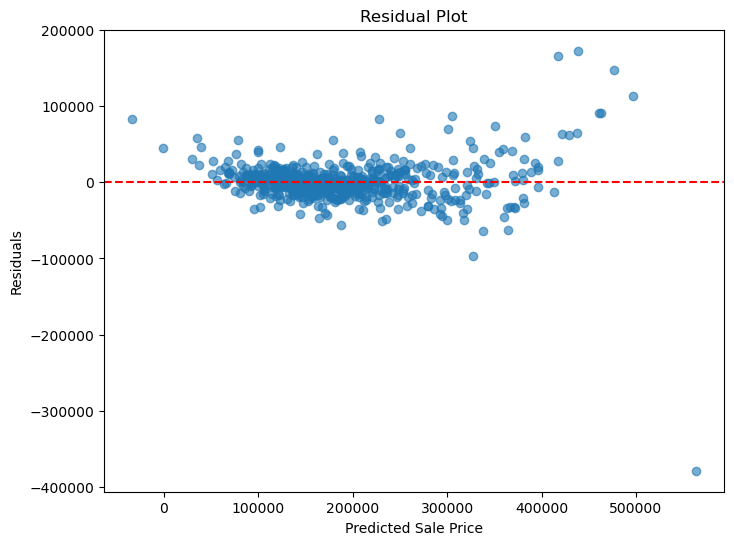

In [57]:
plt.figure(figsize=(8,6))

plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Sale Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.savefig("../images/residual_plot.png", dpi=300, bbox_inches='tight')

plt.show()

## Feature Importance (Coefficient Analysis)

Linear Regression assigns a coefficient to each feature.

- A positive coefficient indicates that an increase in the feature increases the predicted house price.
- A negative coefficient indicates that an increase in the feature decreases the predicted house price.

Coefficient analysis helps identify the most influential features in the model.

In [49]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients.head()

,Feature,Coefficient
0,Order,-1.599218
1,PID,0.000009
2,MS SubClass,-44.682034
3,Lot Frontage,36.628889
4,Lot Area,0.602383


In [50]:
top_positive = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

top_positive.head(10)

,Feature,Coefficient
118,Roof Matl_Membran,662777.865587
123,Roof Matl_WdShngl,658000.050083
119,Roof Matl_Metal,652251.240058
120,Roof Matl_Roll,612340.802166
121,Roof Matl_Tar&Grv,610562.756384
122,Roof Matl_WdShake,601114.743539
117,Roof Matl_CompShg,596338.415592
68,Neighborhood_GrnHill,109105.283190
98,Condition 2_RRAe,76037.415655
237,Garage Cond_TA,59533.280820


In [51]:
top_negative = coefficients.sort_values(
    by='Coefficient'
)

top_negative.head(10)

,Feature,Coefficient
232,Garage Qual_Po,-82708.895258
230,Garage Qual_Fa,-76129.223368
233,Garage Qual_TA,-75609.737416
215,Functional_Sal,-72006.369623
231,Garage Qual_Gd,-54958.707798
130,Exterior 1st_ImStucc,-34657.410249
38,MS Zoning_C (all),-32245.618407
196,Heating_OthW,-31425.280398
207,Kitchen Qual_Fa,-27168.862673
103,Bldg Type_Twnhs,-26548.079633


<Figure size 1000x600 with 0 Axes>

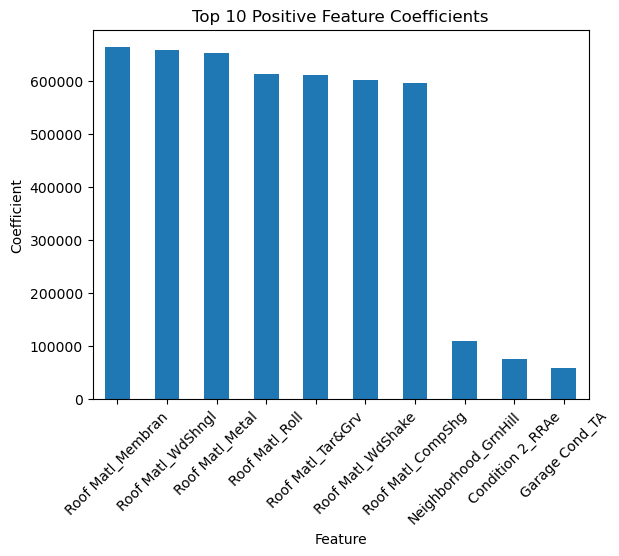

In [58]:
plt.figure(figsize=(10,6))

top_positive.head(10).plot(
    x='Feature',
    y='Coefficient',
    kind='bar',
    legend=False
)

plt.title('Top 10 Positive Feature Coefficients')
plt.ylabel('Coefficient')
plt.xticks(rotation=45)

plt.savefig("../images/positive_coefficients.png", dpi=300, bbox_inches='tight')

plt.show()

<Figure size 1000x600 with 0 Axes>

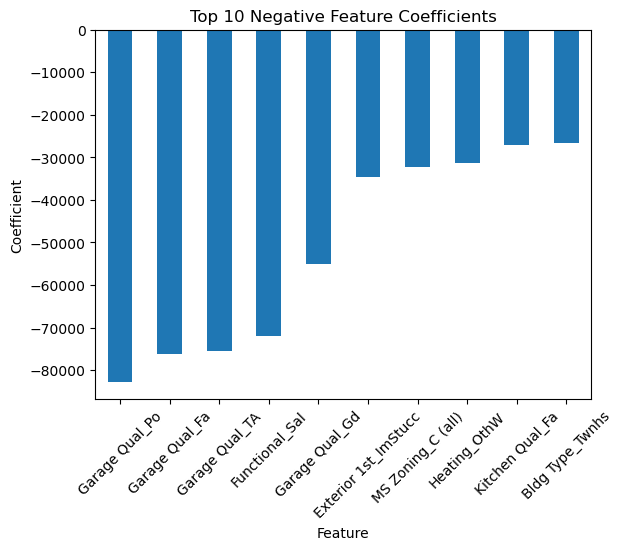

In [59]:
plt.figure(figsize=(10,6))

top_negative.head(10).plot(
    x='Feature',
    y='Coefficient',
    kind='bar',
    legend=False
)

plt.title('Top 10 Negative Feature Coefficients')
plt.ylabel('Coefficient')
plt.xticks(rotation=45)

plt.savefig("../images/negative_coefficients.png", dpi=300, bbox_inches='tight')

plt.show()